In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import fashion_mnist

I0000 00:00:1788285615.668055   16118 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788285615.822356   16118 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788285622.661351   16118 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

In [3]:
model = load_model("model.keras")

model.summary()

E0000 00:00:1788285726.929718   16118 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/anas/LEARNING/GEN-AI/python/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,774 (854.59 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 109,388 (427.30 KB)

In [4]:
(_, _), (X_test, y_test) = fashion_mnist.load_data()

X_test = X_test.astype("float32") / 255.0

In [5]:
index = 100

image = X_test[index]
actual_label = y_test[index]

print("Actual label:", actual_label)
print("Actual class:", class_names[actual_label])

Actual label: 3
Actual class: Dress


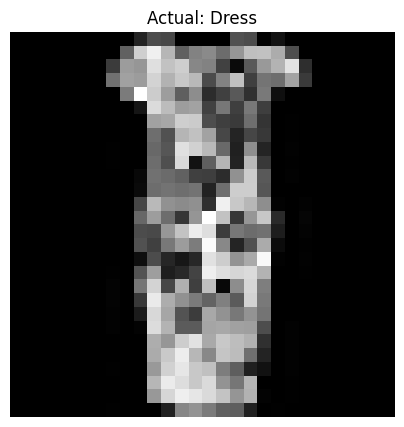

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title(f"Actual: {class_names[actual_label]}")
plt.axis("off")
plt.show()

In [ ]:
image_input = np.expand_dims(image, axis=0)
prediction = model.predict(image_input)
predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class]

print("Predicted class:", predicted_class)
print("Predicted label:", class_names[predicted_class])
print(f"Confidence: {confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
Predicted class: 3
Predicted label: Dress
Confidence: 99.79%


In [ ]:
probabilities = prediction[0]

for i, probability in enumerate(probabilities):
    print(f"{class_names[i]:15s}: " f"{probability * 100:.2f}%")

T-shirt/top    : 0.14%
Trouser        : 0.01%
Pullover       : 0.00%
Dress          : 99.79%
Coat           : 0.01%
Sandal         : 0.00%
Shirt          : 0.05%
Sneaker        : 0.00%
Bag            : 0.00%
Ankle boot     : 0.00%


In [10]:
top_3_indices = np.argsort(probabilities)[-3:][::-1]

print("Top 3 predictions:\n")

for rank, index in enumerate(top_3_indices, start=1):
    print(f"{rank}. {class_names[index]} " f"-> {probabilities[index] * 100:.2f}%")

Top 3 predictions:

1. Dress -> 99.79%
2. T-shirt/top -> 0.14%
3. Shirt -> 0.05%
